In [ ]:
# 07 · Financial Integrity
## **Lens:** Financial / Contract  
## **Audience:** CFO, Managed Care Contracting Team

## | Section | Question |

## | 1 · Revenue Leakage Waterfall | Where does billed revenue go before it becomes cash? |
## | 2 · Net Collection Rate | Which payers are converting allowed revenue to cash? |
## | 3 · Underpayment Analysis | Are payers paying to contracted rate, or underperforming? |
## | 4 · Denial Cost by Payer | Which payer is creating the most unexpected leakage? |
## | 5 · Appeal Recovery Contribution | What is the AR management function actually worth? |

## Tables used: `claim_line`, `claim_header`, `remittance_835`, `denial_forensics`, `appeal_outcomes`, `provider`  
## Self-contained: No cross-notebook dependencies.

In [5]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from src.db import get_connection
from src.personas import PAYER_PERSONAS

con = get_connection(read_only=True)

# Contracted allowed rates — source of truth for underpayment benchmarks
CONTRACTED_RATES = {k: v["allowed_rate"] for k, v in PAYER_PERSONAS.items()}
print("Contracted rates:", CONTRACTED_RATES)

PAYER_COLORS = {
    'medi_cal_managed_care':   '#e63946',
    'commercial_ppo':          '#2a9d8f',
    'medicare_advantage':      '#457b9d',
    'dual_eligible_cobpayer':  '#f4a261',
}

print("\nConnection established.")

Contracted rates: {'medi_cal_managed_care': 0.72, 'commercial_ppo': 0.85, 'medicare_advantage': 0.8, 'dual_eligible_cobpayer': 0.7}

Connection established.


-----
#### Chapter 1 · Revenue Leakage Waterfall
###### Question: Where does billed revenue go before it becomes cash?

###### The waterfall decomposes gross billed into its components: expected contractual write-offs (CO-45), unexpected denial losses, patient responsibility, and net cash collected. Expected losses are a cost of doing business. Unexpected losses are recoverable.

#### **Financial identity per claim line:**  
###### `billed = paid + patient_responsibility + adjustment`

In [6]:
waterfall_data = con.execute("""
    SELECT
        ROUND(SUM(cl.billed_amount), 2)                                       AS gross_billed,
        ROUND(SUM(CASE WHEN r.carc_code = 'CO-45'
                       THEN r.adjustment_amount ELSE 0 END), 2)               AS contractual_adj,
        ROUND(SUM(CASE WHEN r.carc_code NOT IN ('CO-45', 'PR-1')
                        AND r.paid_amount = 0
                       THEN r.adjustment_amount ELSE 0 END), 2)               AS denial_dollars,
        ROUND(SUM(r.patient_responsibility), 2)                               AS patient_resp,
        ROUND(SUM(r.paid_amount), 2)                                          AS net_cash_collected
    FROM claim_line cl
    JOIN remittance_835 r ON cl.claim_line_id = r.claim_line_id
""").df()

appeal_recovery = con.execute("""
    SELECT ROUND(SUM(dollars_recovered), 2) AS total_recovered
    FROM appeal_outcomes
    WHERE appeal_successful = TRUE
""").df()

gross          = waterfall_data["gross_billed"].iloc[0]
contract_adj   = waterfall_data["contractual_adj"].iloc[0]
denials        = waterfall_data["denial_dollars"].iloc[0]
pt_resp        = waterfall_data["patient_resp"].iloc[0]
net_collected  = waterfall_data["net_cash_collected"].iloc[0]
appeal_rec     = appeal_recovery["total_recovered"].iloc[0] or 0
net_revenue    = gross - contract_adj
final_net      = net_collected + appeal_rec
ncr_overall    = round(net_collected / net_revenue * 100, 1) if net_revenue > 0 else 0

print("Revenue Waterfall Summary")
print(f"  Gross Billed:            ${gross:>14,.2f}")
print(f"  Less Contractual Adj.:  -${contract_adj:>14,.2f}  (expected — CO-45)")
print(f"  = Net Revenue:           ${net_revenue:>14,.2f}")
print(f"  Less Denials:           -${denials:>14,.2f}  (unexpected leakage)")
print(f"  Less Patient Resp.:     -${pt_resp:>14,.2f}")
print(f"  = Net Cash Collected:    ${net_collected:>14,.2f}")
print(f"  + Appeal Recovery:      +${appeal_rec:>14,.2f}")
print(f"  = Final Net Position:    ${final_net:>14,.2f}")
print(f"\n  Overall Net Collection Rate: {ncr_overall:.1f}%")
print(f"  Denial leakage as % of net revenue: "
      f"{round(denials/net_revenue*100,1) if net_revenue > 0 else 0:.1f}%")

Revenue Waterfall Summary
  Gross Billed:            $ 88,757,319.06
  Less Contractual Adj.:  -$ 17,090,115.36  (expected — CO-45)
  = Net Revenue:           $ 71,667,203.70
  Less Denials:           -$ 12,447,775.58  (unexpected leakage)
  Less Patient Resp.:     -$  1,486,363.75
  = Net Cash Collected:    $ 57,733,064.37
  + Appeal Recovery:      +$  6,557,399.28
  = Final Net Position:    $ 64,290,463.65

  Overall Net Collection Rate: 80.6%
  Denial leakage as % of net revenue: 17.4%


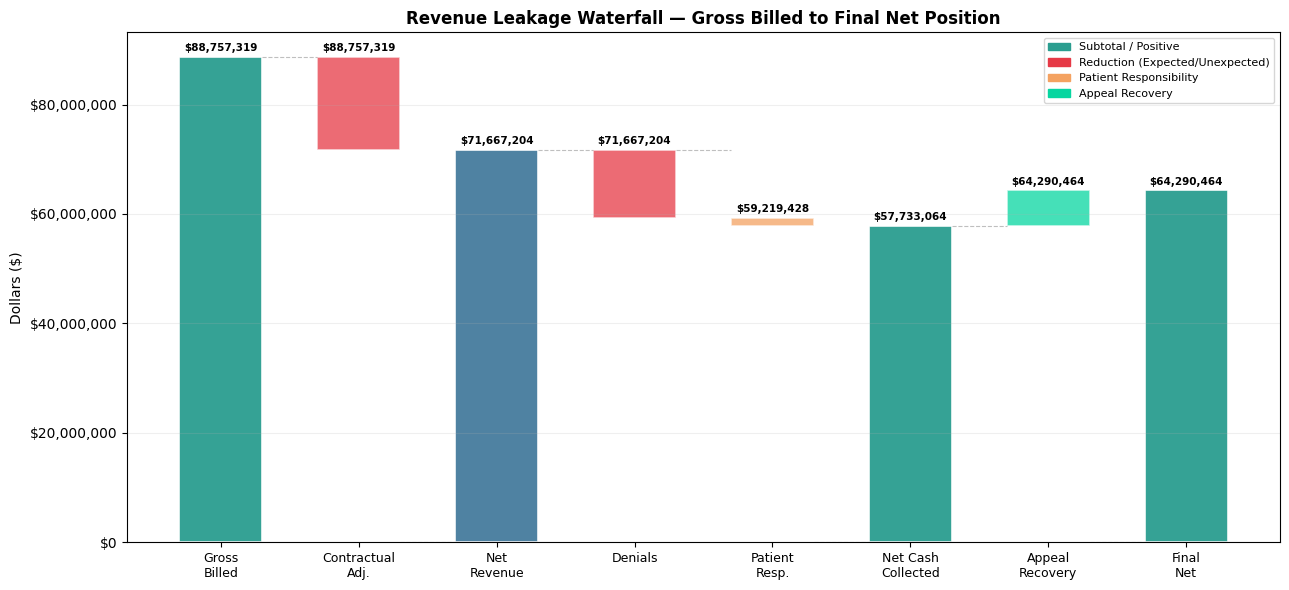

In [7]:
# ── Waterfall chart ─────────────────────────────────────────────────────
labels  = ["Gross\nBilled", "Contractual\nAdj.", "Net\nRevenue",
           "Denials", "Patient\nResp.", "Net Cash\nCollected",
           "Appeal\nRecovery", "Final\nNet"]

# Each stage: (bottom, height, is_total)
stages = [
    (0,                            gross,         True,  "#2a9d8f"),   # Gross
    (net_revenue,                  contract_adj,  False, "#e63946"),   # Contractual adj
    (0,                            net_revenue,   True,  "#457b9d"),   # Net revenue
    (net_revenue - denials,        denials,       False, "#e63946"),   # Denials
    (net_collected,                pt_resp,       False, "#f4a261"),   # Patient resp
    (0,                            net_collected, True,  "#2a9d8f"),   # Net collected
    (net_collected,                appeal_rec,    False, "#06d6a0"),   # Appeal recovery
    (0,                            final_net,     True,  "#2a9d8f"),   # Final net
]

fig, ax = plt.subplots(figsize=(13, 6))
x = range(len(stages))

for i, (bottom, height, is_total, color) in enumerate(stages):
    alpha = 0.95 if is_total else 0.75
    ax.bar(i, height, bottom=bottom, color=color, alpha=alpha,
           edgecolor="white", linewidth=1.2, width=0.6)
    label_y = bottom + height + gross * 0.008
    ax.text(i, label_y, f"${bottom + height:,.0f}",
            ha="center", va="bottom", fontsize=7.5, fontweight="bold")

# Connector lines between bars
for i in range(len(stages) - 1):
    b0, h0, t0, _ = stages[i]
    b1, h1, t1, _ = stages[i + 1]
    connect_y = b0 + h0 if not t1 else b1
    ax.plot([i + 0.3, i + 0.7], [connect_y, connect_y],
            color="gray", linewidth=0.8, linestyle="--", alpha=0.5)

ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Dollars ($)")
ax.set_title("Revenue Leakage Waterfall — Gross Billed to Final Net Position",
             fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.grid(axis="y", alpha=0.2)

legend_elements = [
    mpatches.Patch(color="#2a9d8f", label="Subtotal / Positive"),
    mpatches.Patch(color="#e63946", label="Reduction (Expected/Unexpected)"),
    mpatches.Patch(color="#f4a261", label="Patient Responsibility"),
    mpatches.Patch(color="#06d6a0", label="Appeal Recovery"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

-------
#### Chapter 2 · Net Collection Rate by Payer
###### Question: Which payers are converting allowed revenue to cash?

###### NCR = net cash collected / net revenue (billed minus contractual adjustments).  
###### A high NCR against a low contracted rate (Medi-Cal) can still outperform a low NCR against a high contracted rate (commercial PPO) — what matters is the realized yield.

Net Collection Rate by Payer

              payer_id  claim_count  gross_billed  contractual_adj  net_revenue  net_collected  ncr_pct  denial_leakage_pct
        commercial_ppo         7435   26466708.68       3580201.53  22886507.15    19824057.20     86.6                 9.8
    medicare_advantage         4997   17672483.09       3100020.50  14572462.59    12098498.60     83.0                12.3
 medi_cal_managed_care        11336   40027309.35       9415528.67  30611780.68    23549700.12     76.9                16.0
dual_eligible_cobpayer         1232    4590817.94        994364.66   3596453.28     2260808.45     62.9                27.8


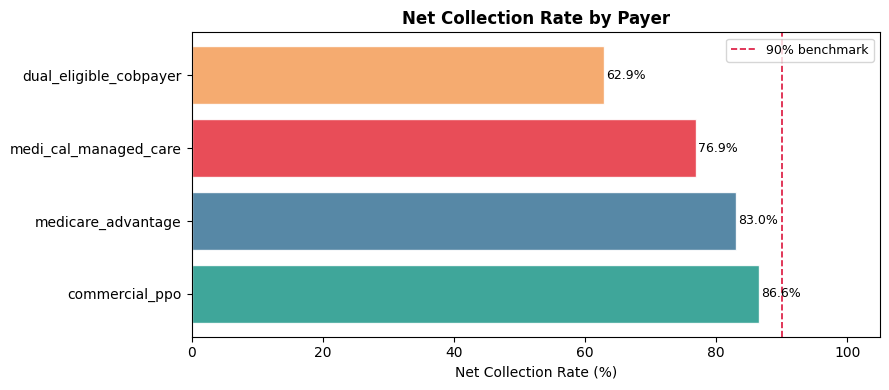

In [8]:
ncr_by_payer = con.execute("""
    SELECT
        ch.payer_id,
        COUNT(DISTINCT ch.claim_id)                                            AS claim_count,
        ROUND(SUM(cl.billed_amount), 2)                                        AS gross_billed,
        ROUND(SUM(CASE WHEN r.carc_code = 'CO-45'
                       THEN r.adjustment_amount ELSE 0 END), 2)               AS contractual_adj,
        ROUND(SUM(cl.billed_amount)
              - SUM(CASE WHEN r.carc_code = 'CO-45'
                         THEN r.adjustment_amount ELSE 0 END), 2)             AS net_revenue,
        ROUND(SUM(r.paid_amount), 2)                                           AS net_collected,
        ROUND(100.0 * SUM(r.paid_amount) /
              NULLIF(SUM(cl.billed_amount)
                     - SUM(CASE WHEN r.carc_code = 'CO-45'
                               THEN r.adjustment_amount ELSE 0 END), 0), 1)  AS ncr_pct,
        ROUND(100.0 * SUM(CASE WHEN r.carc_code NOT IN ('CO-45', 'PR-1')
                               AND r.paid_amount = 0
                               THEN r.adjustment_amount ELSE 0 END)
              / NULLIF(SUM(cl.billed_amount), 0), 1)                          AS denial_leakage_pct
    FROM claim_line cl
    JOIN claim_header ch   ON cl.claim_id = ch.claim_id
    JOIN remittance_835 r  ON cl.claim_line_id = r.claim_line_id
    GROUP BY ch.payer_id
    ORDER BY ncr_pct DESC
""").df()

print("Net Collection Rate by Payer\n")
print(ncr_by_payer.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = [PAYER_COLORS.get(p, "#adb5bd") for p in ncr_by_payer["payer_id"]]
bars = ax.barh(ncr_by_payer["payer_id"], ncr_by_payer["ncr_pct"],
               color=colors, edgecolor="white", alpha=0.9)
ax.axvline(90, color="crimson", linestyle="--", linewidth=1.2, label="90% benchmark")
for bar, val in zip(bars, ncr_by_payer["ncr_pct"]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
ax.set_xlabel("Net Collection Rate (%)")
ax.set_title("Net Collection Rate by Payer", fontsize=12, fontweight="bold")
ax.set_xlim(0, 105)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

--------
#### Chapter 3 · Underpayment Analysis
###### Question: Are payers paying to contracted rate, or underperforming the contract?

###### Underpayment occurs when a payer's effective allowed rate — the actual dollars paid relative to billed — falls below the contracted rate. Systematic underpayment that goes undetected becomes permanent revenue loss. This is what managed care contracting teams exist to identify and dispute.

###### **Effective yield** = (paid + patient responsibility) / gross billed  
###### **Contracted yield** = allowed rate from payer contract  
###### **Gap** = effective yield − contracted yield

Underpayment Analysis

              payer_id  contracted_rate_pct  effective_yield_pct  yield_gap_pct  underpayment_dollars
dual_eligible_cobpayer                 70.0                50.54         -19.46             893373.17
 medi_cal_managed_care                 72.0                60.49         -11.51            4607143.31
    medicare_advantage                 80.0                70.17          -9.83            1737205.09
        commercial_ppo                 85.0                76.65          -8.35            2209970.17


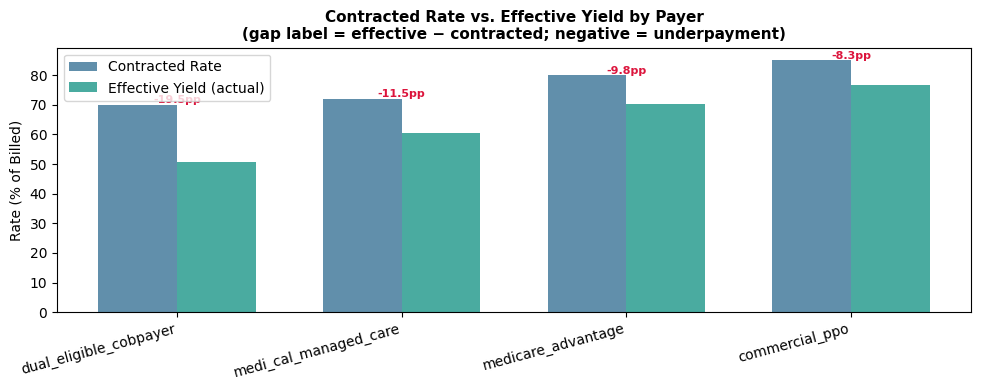


Total underpayment exposure: $9,447,691.74
Payers below contracted rate:
              payer_id  yield_gap_pct  underpayment_dollars
dual_eligible_cobpayer         -19.46             893373.17
 medi_cal_managed_care         -11.51            4607143.31
    medicare_advantage          -9.83            1737205.09
        commercial_ppo          -8.35            2209970.17


In [10]:
underpayment = con.execute("""
    SELECT
        ch.payer_id,
        ROUND(SUM(cl.billed_amount), 2)                                  AS gross_billed,
        ROUND(SUM(r.allowed_amount), 2)                                  AS total_allowed,
        ROUND(SUM(r.paid_amount + r.patient_responsibility), 2)          AS total_realized,
        ROUND(100.0 * SUM(r.allowed_amount)
              / NULLIF(SUM(cl.billed_amount), 0), 2)                     AS effective_allowed_rate_pct,
        ROUND(100.0 * SUM(r.paid_amount + r.patient_responsibility)
              / NULLIF(SUM(cl.billed_amount), 0), 2)                     AS effective_yield_pct
    FROM claim_line cl
    JOIN claim_header ch   ON cl.claim_id = ch.claim_id
    JOIN remittance_835 r  ON cl.claim_line_id = r.claim_line_id
    GROUP BY ch.payer_id
    ORDER BY effective_yield_pct ASC
""").df()

# Add contracted rate and compute gap
underpayment["contracted_rate_pct"] = (
    underpayment["payer_id"].map(CONTRACTED_RATES) * 100
).round(1)
underpayment["yield_gap_pct"] = (
    underpayment["effective_yield_pct"] - underpayment["contracted_rate_pct"]
).round(2)
underpayment["underpayment_dollars"] = (
    underpayment["gross_billed"]
    * (underpayment["contracted_rate_pct"] - underpayment["effective_yield_pct"])
    / 100
).round(2)

print("Underpayment Analysis\n")
print(underpayment[[
    "payer_id", "contracted_rate_pct", "effective_yield_pct",
    "yield_gap_pct", "underpayment_dollars"
]].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(underpayment))
width = 0.35
ax.bar(x - width/2, underpayment["contracted_rate_pct"], width,
       label="Contracted Rate", color="#457b9d", alpha=0.85)
ax.bar(x + width/2, underpayment["effective_yield_pct"], width,
       label="Effective Yield (actual)", color="#2a9d8f", alpha=0.85)

for i, (c, e) in enumerate(zip(
    underpayment["contracted_rate_pct"], underpayment["effective_yield_pct"]
)):
    gap = e - c
    color = "crimson" if gap < -0.5 else "green" if gap > 0.5 else "gray"
    label = f"{gap:+.1f}pp"
    ax.text(i, max(c, e) + 0.5, label, ha="center", fontsize=8,
            color=color, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(underpayment["payer_id"], rotation=15, ha="right")
ax.set_ylabel("Rate (% of Billed)")
ax.set_title("Contracted Rate vs. Effective Yield by Payer\n"
             "(gap label = effective − contracted; negative = underpayment)",
             fontsize=11, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

underpaid = underpayment[underpayment["underpayment_dollars"] > 0]
if not underpaid.empty:
    total_under = underpaid["underpayment_dollars"].sum()
    print(f"\nTotal underpayment exposure: ${total_under:,.2f}")
    print("Payers below contracted rate:")
    print(underpaid[["payer_id","yield_gap_pct","underpayment_dollars"]].to_string(index=False))
else:
    print("\nNo systematic underpayment detected — effective yields at or above contracted rates.")

------
#### Chapter 4 · Denial Cost by Payer
###### Question: Which payer is creating the most unexpected revenue leakage?

###### Contractual adjustments (CO-45) are expected and priced into the contract. Everything else — denials — represents dollars the organization expected to collect and didn't. Broken down by payer and denial type, this becomes the basis for payer-specific contract renegotiation arguments.

Denial Cost by Payer and CARC Code

              payer_id carc_code          denial_category  denial_count  dollars_at_risk  avg_recovery_prob  expected_recoverable
        commercial_ppo      CO-4             coding_error           956       1300307.09               0.70             910214.96
        commercial_ppo     CO-57            authorization           182        470290.75               0.55             258659.91
        commercial_ppo     CO-16      missing_information           440        449939.80               0.72             323956.66
        commercial_ppo     CO-50        medical_necessity            87        235839.12               0.35              82543.69
        commercial_ppo     CO-97                 bundling            65         75719.72               0.65              49217.82
        commercial_ppo     CO-B7   provider_credentialing           455         66608.79               0.15               9991.32
dual_eligible_cobpayer     CO-22 coordination_of_benef

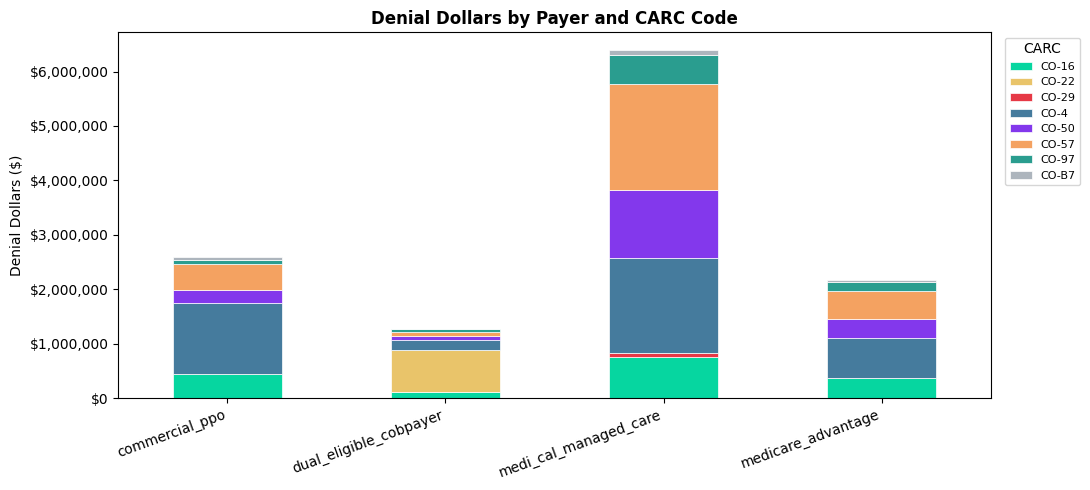


Payer Denial Summary:
                        denial_count  dollars_at_risk  expected_recoverable  unrecoverable
payer_id                                                                                  
medi_cal_managed_care           5059       6400419.53            3646166.47     2754253.06
commercial_ppo                  2185       2598705.27            1634584.36      964120.91
medicare_advantage              1823       2172378.93            1295064.75      877314.18
dual_eligible_cobpayer          1022       1276271.85             735229.63      541042.22


In [11]:
denial_by_payer = con.execute("""
    SELECT
        ch.payer_id,
        df.carc_code,
        df.denial_category,
        COUNT(*)                            AS denial_count,
        ROUND(SUM(df.dollars_at_risk), 2)   AS dollars_at_risk,
        ROUND(AVG(df.recovery_probability), 3) AS avg_recovery_prob,
        ROUND(SUM(df.dollars_at_risk * df.recovery_probability), 2) AS expected_recoverable
    FROM denial_forensics df
    JOIN remittance_835 r  ON df.claim_line_id = r.claim_line_id
    JOIN claim_header ch   ON r.claim_id = ch.claim_id
    GROUP BY ch.payer_id, df.carc_code, df.denial_category
    ORDER BY ch.payer_id, dollars_at_risk DESC
""").df()

print("Denial Cost by Payer and CARC Code\n")
print(denial_by_payer.to_string(index=False))

# Stacked bar: denial dollars by payer, colored by CARC
pivot = denial_by_payer.pivot_table(
    index="payer_id", columns="carc_code",
    values="dollars_at_risk", aggfunc="sum"
).fillna(0)

carc_colors = {
    'CO-29': '#e63946', 'CO-57': '#f4a261', 'CO-97': '#2a9d8f',
    'CO-4':  '#457b9d', 'CO-50': '#8338ec', 'CO-22': '#e9c46a',
    'CO-16': '#06d6a0', 'CO-B7': '#adb5bd',
}

ax = pivot.plot(kind="bar", stacked=True, figsize=(11, 5),
                color=[carc_colors.get(c, "#cccccc") for c in pivot.columns],
                edgecolor="white", linewidth=0.5)
ax.set_xlabel("")
ax.set_ylabel("Denial Dollars ($)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.set_title("Denial Dollars by Payer and CARC Code", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.legend(title="CARC", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# Payer-level summary
payer_denial_summary = (
    denial_by_payer.groupby("payer_id")[["denial_count","dollars_at_risk","expected_recoverable"]]
    .sum().sort_values("dollars_at_risk", ascending=False)
)
payer_denial_summary["unrecoverable"] = (
    payer_denial_summary["dollars_at_risk"] - payer_denial_summary["expected_recoverable"]
).round(2)
print("\nPayer Denial Summary:")
print(payer_denial_summary.to_string())

-----
#### Chapter 5 · Appeal Recovery Contribution
###### Question: What is the AR management function actually worth?

###### Denial management and appeals work is often treated as a cost center. This section quantifies it as a revenue function — dollars recovered, success rates by CARC code, and the net contribution to final NCR. The delta between a well-run and a poorly-run appeals function is the business case for investing in it.

In [12]:
appeal_summary = con.execute("""
    SELECT
        ao.carc_code,
        COUNT(*)                                             AS total_appeals,
        SUM(CASE WHEN ao.appeal_successful THEN 1 ELSE 0 END) AS successful,
        ROUND(100.0 * SUM(CASE WHEN ao.appeal_successful THEN 1 ELSE 0 END)
              / NULLIF(COUNT(*), 0), 1)                      AS success_rate_pct,
        ROUND(SUM(ao.dollars_at_risk), 2)                    AS total_at_risk,
        ROUND(SUM(ao.dollars_recovered), 2)                  AS total_recovered,
        ROUND(100.0 * SUM(ao.dollars_recovered)
              / NULLIF(SUM(ao.dollars_at_risk), 0), 1)       AS recovery_rate_pct,
        ROUND(AVG(ao.days_to_resolve), 1)                    AS avg_days_to_resolve,
        ROUND(AVG(ao.recovery_rate_est), 3)                  AS model_est_rate,
        ROUND(AVG(ao.recovery_rate_act), 3)                  AS actual_rate
    FROM appeal_outcomes ao
    GROUP BY ao.carc_code
    ORDER BY total_recovered DESC
""").df()

print("Appeal Recovery by CARC Code\n")
print(appeal_summary.to_string(index=False))

total_at_risk  = appeal_summary["total_at_risk"].sum()
total_recovered = appeal_summary["total_recovered"].sum()
overall_success = appeal_summary["successful"].sum() / appeal_summary["total_appeals"].sum() * 100

print(f"\nAppeal Portfolio Summary:")
print(f"  Total denial dollars taken to appeal: ${total_at_risk:,.2f}")
print(f"  Total recovered via appeal:           ${total_recovered:,.2f}")
print(f"  Overall appeal success rate:          {overall_success:.1f}%")
print(f"  Recovery as % of at-risk dollars:     "
      f"{round(total_recovered/total_at_risk*100,1) if total_at_risk > 0 else 0:.1f}%")

Appeal Recovery by CARC Code

carc_code  total_appeals  successful  success_rate_pct  total_at_risk  total_recovered  recovery_rate_pct  avg_days_to_resolve  model_est_rate  actual_rate
     CO-4           3276      2269.0              69.3     3981335.76       2617784.18               65.8                 21.9            0.70        0.624
    CO-57           1281       613.0              47.9     2986941.52       1421049.18               47.6                 59.1            0.55        0.432
    CO-16           1591      1131.0              71.1     1680743.15       1094907.34               65.1                 14.6            0.72        0.639
    CO-50            759       243.0              32.0     1903690.02        543044.48               28.5                 82.0            0.35        0.289
    CO-97            634       400.0              63.1      836811.06        479931.44               57.4                 31.6            0.65        0.562
    CO-22            595       315

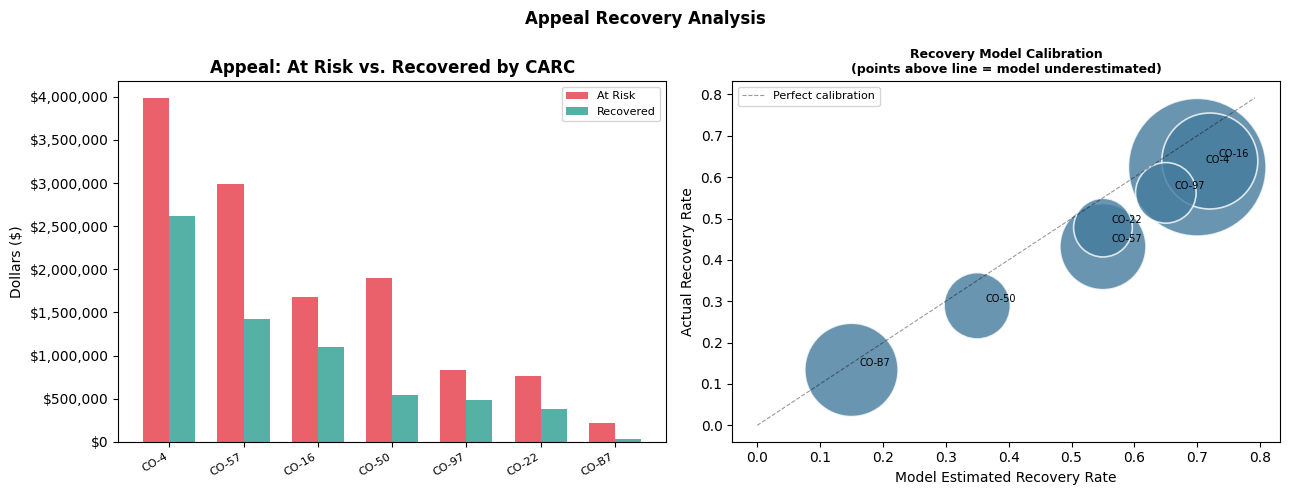

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: dollars at risk vs recovered by CARC
x = np.arange(len(appeal_summary))
width = 0.35
ax1.bar(x - width/2, appeal_summary["total_at_risk"], width,
        label="At Risk", color="#e63946", alpha=0.8)
ax1.bar(x + width/2, appeal_summary["total_recovered"], width,
        label="Recovered", color="#2a9d8f", alpha=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(appeal_summary["carc_code"], rotation=30, ha="right", fontsize=8)
ax1.set_ylabel("Dollars ($)")
ax1.set_title("Appeal: At Risk vs. Recovered by CARC", fontweight="bold")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax1.legend(fontsize=8)

# Right: model estimate vs actual recovery rate (calibration check)
ax2.scatter(appeal_summary["model_est_rate"], appeal_summary["actual_rate"],
            s=appeal_summary["total_appeals"] * 3,
            color="#457b9d", alpha=0.8, edgecolors="white", linewidth=1.2)
for _, row in appeal_summary.iterrows():
    ax2.annotate(row["carc_code"],
                 (row["model_est_rate"], row["actual_rate"]),
                 textcoords="offset points", xytext=(6, 3), fontsize=7)
max_rate = max(appeal_summary[["model_est_rate","actual_rate"]].max()) * 1.1
ax2.plot([0, max_rate], [0, max_rate], "k--", linewidth=0.8,
         alpha=0.4, label="Perfect calibration")
ax2.set_xlabel("Model Estimated Recovery Rate")
ax2.set_ylabel("Actual Recovery Rate")
ax2.set_title("Recovery Model Calibration\n(points above line = model underestimated)",
              fontweight="bold", fontsize=9)
ax2.legend(fontsize=8)

plt.suptitle("Appeal Recovery Analysis", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

#### Summary · Financial Position Statement

###### This notebook assembles the complete financial picture in one place — the view a CFO or contracting director needs to evaluate revenue cycle performance:

###### **Revenue integrity:** Does the waterfall match expectations? Contractual adjustments should be predictable; denial losses should not be. If denial dollars are material relative to contractual adjustments, that's a revenue cycle efficiency problem, not a contract problem.

###### **Payer performance:** NCR and effective yield by payer show whether each contract is delivering its promised economics. A payer with a high contracted rate but low effective yield is creating hidden leakage that doesn't appear in the contract itself — it appears in denial volume and slow adjudication.

###### **Underpayment exposure:** Systematic gaps between contracted and effective rates compound silently over time. Contracting teams that review these gaps at renewal have a documented basis for rate adjustments. Those that don't leave revenue on the table permanently.

###### **Appeal ROI:** The calibration plot in Section 5 shows whether the recovery probability model is over- or under-estimating actual success rates by CARC code. Points above the diagonal: the model was conservative — actual recovery was better than predicted. Points below: the model was optimistic — actual recovery disappointed. Calibrating this model with real data improves AR prioritization decisions over time.
